## 4. Display the PSF from coadd images

This notebook shows how to load a coadd image from the `lsst-ir-fusion` Butler repository and display its point-spread function (PSF).

The goal is intentionally simple:

- connect to the Butler
- find the main coadd collection
- choose one tract, patch, and band
- load one `deepCoadd_calexp`
- evaluate and display the PSF at the centre of the image

This is useful for a quick visual check of the image quality and the PSF model stored with the coadd.

### 4.1 Import packages

We use the Rubin/LSST Butler to access the data, and `matplotlib` to display the PSF image inside the notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import lsst.daf.butler as dafButler
import lsst.geom

### 4.2 Open the Butler repository

The fused HSC-VISTA products are available from the Butler repository called `lsst-ir-fusion` on the RSP.

In [2]:
butler = dafButler.Butler("lsst-ir-fusion")
registry = butler.registry

print("Butler repository opened successfully")

Butler repository opened successfully


### 4.3 Find the coadd collection

Here we look for the coadd-detection collection automatically. This avoids hard-coding the full timestamped collection name.

In [3]:
all_collections = sorted(registry.queryCollections())

coadd_matches = [c for c in all_collections if "videoCoaddDetect" in c]

print("Coadd collections:")
for c in coadd_matches:
    print(" ", c)

if not coadd_matches:
    raise RuntimeError("No videoCoaddDetect collection was found.")

coadd_collection = coadd_matches[0]
print("Selected coadd_collection =", coadd_collection)

Coadd collections:
  u/dc-park2/DRP/videoCoaddDetect/20260116T115441Z
Selected coadd_collection = u/dc-park2/DRP/videoCoaddDetect/20260116T115441Z


### 4.4 Open a Butler using the selected collection

This makes later `butler.get` calls shorter, because the collection is already attached to this Butler object.

In [4]:
coadd_butler = dafButler.Butler("lsst-ir-fusion", collections=coadd_collection)
print("Coadd Butler is ready")

Coadd Butler is ready


### 4.5 Select one coadd image

Choose one tract, patch, and band. You can change these values to inspect a different region or band.

In [5]:
skymap_name = "hscPdr2"
my_tract = 8525
my_patch = 70
my_band = "K"

sample_data_id = {
    "skymap": skymap_name,
    "tract": my_tract,
    "patch": my_patch,
    "band": my_band,
}

print("Selected data ID:")
print(sample_data_id)

Selected data ID:
{'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70, 'band': 'K'}


### 4.6 Load the coadd image

The `deepCoadd_calexp` contains the image, mask, variance plane, WCS, photometric calibration, and PSF model.

In [6]:
my_deepCoadd = coadd_butler.get("deepCoadd_calexp", **sample_data_id)

print("Loaded deepCoadd_calexp")
print("BBox width  :", my_deepCoadd.getBBox().getWidth())
print("BBox height :", my_deepCoadd.getBBox().getHeight())
print("Has PSF     :", my_deepCoadd.hasPsf())

Loaded deepCoadd_calexp
BBox width  : 4200
BBox height : 4200
Has PSF     : True


### 4.7 Choose the PSF position

The PSF can vary across the image. Here we evaluate it at the centre of the coadd. For a first visual check, this is usually a good simple choice.

In [7]:
bbox = my_deepCoadd.getBBox()

x_cen = 0.5 * (bbox.getMinX() + bbox.getMaxX())
y_cen = 0.5 * (bbox.getMinY() + bbox.getMaxY())

psf_position = lsst.geom.Point2D(x_cen, y_cen)

print("PSF position:")
print("x =", x_cen)
print("y =", y_cen)

PSF position:
x = 29999.5
y = 29999.5


### 4.8 Compute and display the PSF image

We now ask the coadd PSF model for an image at the selected position. The result is a small postage stamp of the model PSF.

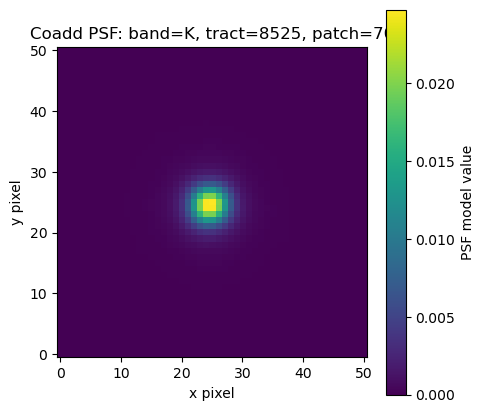

PSF image shape: (51, 51)
PSF sum: 0.9997778811029243


In [8]:
psf = my_deepCoadd.getPsf()
psf_image = psf.computeImage(psf_position)
psf_array = psf_image.array

plt.figure(figsize=(5, 5))
plt.imshow(psf_array, origin="lower", interpolation="nearest")
plt.colorbar(label="PSF model value")
plt.title(f"Coadd PSF: band={my_band}, tract={my_tract}, patch={my_patch}")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.show()

print("PSF image shape:", psf_array.shape)
print("PSF sum:", np.nansum(psf_array))

### 4.9 Display the PSF radial profile

A radial profile is a simple way to see the width and shape of the PSF model.

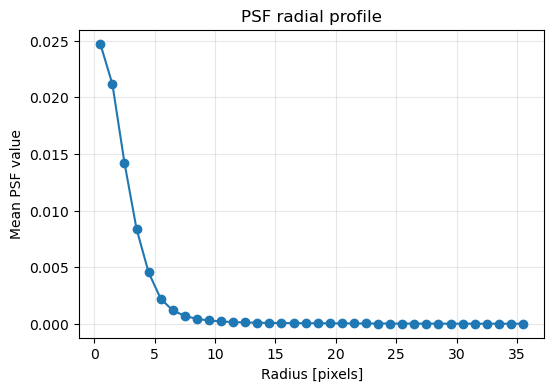

In [9]:
y, x = np.indices(psf_array.shape)
xc = 0.5 * (psf_array.shape[1] - 1)
yc = 0.5 * (psf_array.shape[0] - 1)
r = np.sqrt((x - xc)**2 + (y - yc)**2)

r_flat = r.ravel()
psf_flat = psf_array.ravel()

bins = np.arange(0, r_flat.max() + 1, 1)
r_mid = 0.5 * (bins[:-1] + bins[1:])
profile = []

for r0, r1 in zip(bins[:-1], bins[1:]):
    m = (r_flat >= r0) & (r_flat < r1)
    if np.any(m):
        profile.append(np.nanmean(psf_flat[m]))
    else:
        profile.append(np.nan)

profile = np.asarray(profile)

plt.figure(figsize=(6, 4))
plt.plot(r_mid, profile, marker="o")
plt.xlabel("Radius [pixels]")
plt.ylabel("Mean PSF value")
plt.title("PSF radial profile")
plt.grid(alpha=0.3)
plt.show()

### 4.10 Compare PSFs at several positions

As a slightly more useful check, we can evaluate the PSF at the centre and near four corners of the coadd. This gives a quick visual impression of whether the PSF changes across the image.

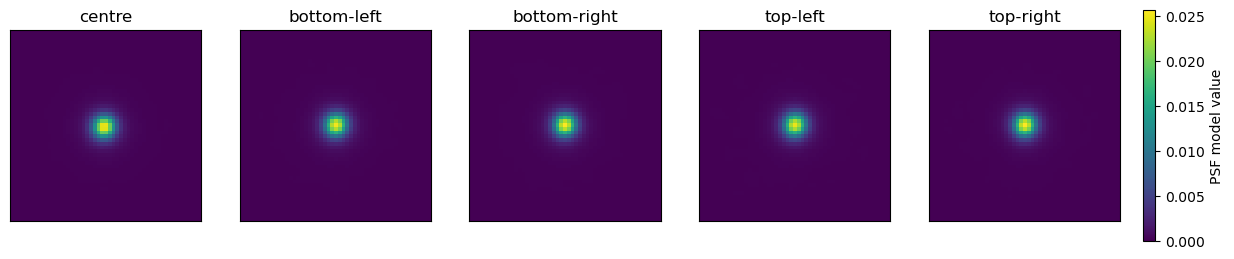

In [10]:
bbox = my_deepCoadd.getBBox()
margin = 200

positions = {
    "centre": lsst.geom.Point2D(x_cen, y_cen),
    "bottom-left": lsst.geom.Point2D(bbox.getMinX() + margin, bbox.getMinY() + margin),
    "bottom-right": lsst.geom.Point2D(bbox.getMaxX() - margin, bbox.getMinY() + margin),
    "top-left": lsst.geom.Point2D(bbox.getMinX() + margin, bbox.getMaxY() - margin),
    "top-right": lsst.geom.Point2D(bbox.getMaxX() - margin, bbox.getMaxY() - margin),
}

psf_stamps = {}
for name, pos in positions.items():
    psf_stamps[name] = psf.computeImage(pos).array

vmin = min(np.nanmin(a) for a in psf_stamps.values())
vmax = max(np.nanmax(a) for a in psf_stamps.values())

fig, axes = plt.subplots(1, len(psf_stamps), figsize=(15, 3))

for ax, (name, arr) in zip(axes, psf_stamps.items()):
    im = ax.imshow(arr, origin="lower", interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="PSF model value")
plt.show()

### 4.11 Optional: save the PSF image

This cell saves the centre PSF stamp as a NumPy array. This is useful if you want to compare PSFs later without reloading the Butler data.

In [11]:
output_name = f"psf_{my_band}_tract{my_tract}_patch{my_patch}.npy"
#np.save(output_name, psf_array)

print("Saved:", output_name)

Saved: psf_K_tract8525_patch70.npy


## Summary

In this notebook we loaded one `deepCoadd_calexp`, extracted the PSF model stored with it, displayed the PSF at the image centre, and compared PSF stamps at several image positions.

This provides a simple first check of the PSF information available in the fused HSC-VISTA coadd products.